In [1]:
#Load the libraries 
import pandas as pd 
import matplotlib.pyplot as plt 

In [22]:
#Load the dataset
df = pd.read_csv(r"C:\Users\marya\OneDrive\Desktop\fintech\finpay-data-analytics-roadmap\datasets\transactions_merchant_master.csv")

In [21]:
#Displays the dataframe
df

,transaction_id,customer_id,merchant_id,transaction_date,amount,payment_method,transaction_status,installment_months,cashback,wallet_used,merchant_name,category,city,country,onboarding_date,commission_rate,rating,active_status
0,1,80,2,2024-06-05,923.09,Card,Success,12,18.46,True,Merchant2,Travel,Doha,Qatar,2024-11-15,2.52,3.1,True
1,2,11,6,2024-03-02,801.29,Apple Pay,Success,3,16.03,True,Merchant6,Restaurant,Abu Dhabi,UAE,2025-03-22,1.07,3.6,True
2,3,89,20,2024-04-30,1231.47,Google Pay,Success,3,24.63,False,Merchant20,Restaurant,Abu Dhabi,UAE,2024-03-29,2.19,4.2,True
3,4,90,15,2024-01-19,2123.80,Apple Pay,Failed,12,42.48,True,Merchant15,Electronics,Riyadh,Saudi Arabia,2024-08-10,2.14,4.0,True
4,5,70,8,2024-06-14,1281.17,Apple Pay,Failed,3,25.62,True,Merchant8,Restaurant,Dubai,UAE,2025-02-02,3.20,3.7,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,52,20,2024-06-16,2792.75,Google Pay,Success,3,55.86,False,Merchant20,Restaurant,Abu Dhabi,UAE,2024-03-29,2.19,4.2,True
496,497,26,17,2024-03-14,1322.53,Apple Pay,Success,12,26.45,True,Merchant17,Restaurant,Abu Dhabi,UAE,2023-03-17,3.31,4.4,True
497,498,87,2,2024-04-02,1849.42,Apple Pay,Success,3,36.99,True,Merchant2,Travel,Doha,Qatar,2024-11-15,2.52,3.1,True
498,499,100,13,2024-03-31,2990.48,Wallet,Failed,12,59.81,True,Merchant13,Electronics,Dubai,UAE,2024-12-26,3.14,3.5,True


In [3]:
#Revenue by Merchant Category 
revenue_category = pd.pivot_table(df,values="amount",index = "category",aggfunc="sum")
revenue_category

,amount
category,
Electronics,186793.81
Grocery,161022.62
Restaurant,220859.30
Travel,177922.91


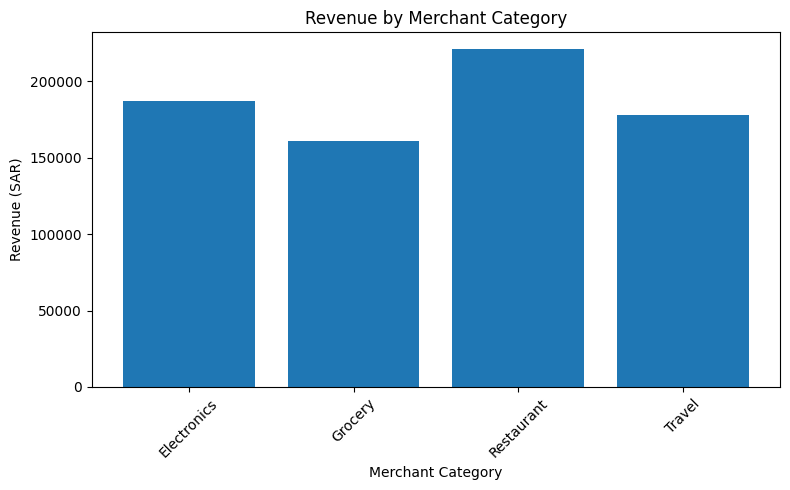

In [4]:
#Bar chart 
plt.figure(figsize=(8,5)) #Create a new figure and set its size    
#plt.bar(x,y) x=categories y=values
plt.bar(revenue_category.index, #this is the different catgories
        revenue_category["amount"]) #this is the sum of the amount of the revenue

plt.title("Revenue by Merchant Category") #adds a chart title
plt.xlabel("Merchant Category") #labels the x-axis 
plt.ylabel("Revenue (SAR)") #labels the y-axis
plt.xticks(rotation=45) #rotates the category names by 45 degrees so they don't overlap

plt.tight_layout() #automatically adjusts spacing so labels and titles fit within the figure
plt.show() #displays the chart


Possible Insights:

Restaurant generates more revenue 
Grocery generates less revenue

Business Actions:

Strengthen relations with restaurant merchants
Identify why the grocery merchant generates less revenue

Revenue by Payment Method

In [5]:
revenue_payment = pd.pivot_table(df,values="amount",index="payment_method",aggfunc="sum")
revenue_payment

,amount
payment_method,
Apple Pay,176250.72
Card,161435.34
Google Pay,229172.58
Wallet,179740.00


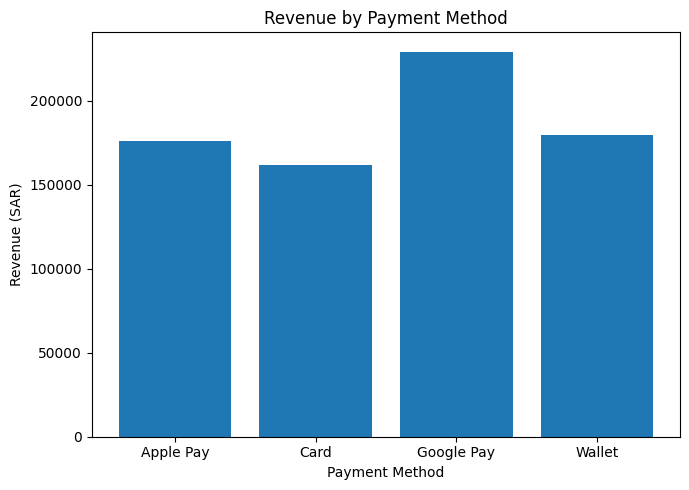

In [6]:
#Bar chart
plt.figure(figsize=(7,5))
plt.bar(revenue_payment.index,
revenue_payment["amount"])

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue (SAR)")

plt.tight_layout()
plt.show()

Possible insights:
Google Pay generated the highest revenue
Card contributed the lowest revenue 

Business actions:
Continue promoting Google Pay through partnerships,cashback offers or exclusive discounts to maintain strong customer adoption

Top 10 Merchants by Revenue

In [7]:
top_merchants = df.groupby("merchant_name")["amount"].sum().sort_values(ascending=False).head(10)
top_merchants

merchant_name
Merchant2     50432.04
Merchant16    49256.89
Merchant18    45140.36
Merchant20    45043.19
Merchant15    43959.26
Merchant3     42115.41
Merchant10    42069.30
Merchant5     40467.96
Merchant19    40281.21
Merchant17    36696.60
Name: amount, dtype: float64

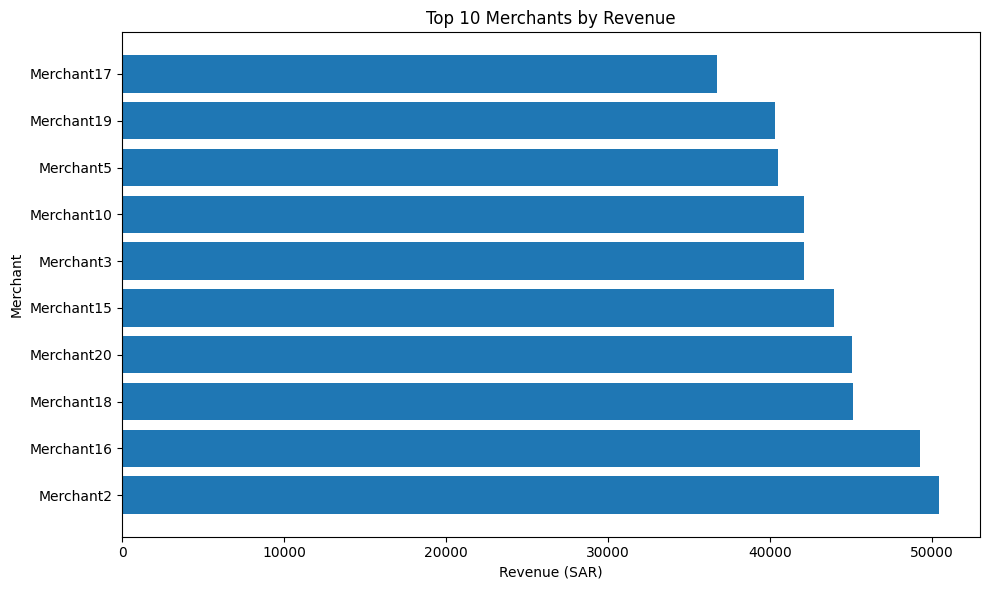

In [8]:
#Horizontal bar chart
plt.figure(figsize=(10,6))

#horizontal bar chart
plt.barh(                       
    top_merchants.index,
    top_merchants.values
)

plt.title("Top 10 Merchants by Revenue")
plt.xlabel("Revenue (SAR)")
plt.ylabel("Merchant")
plt.tight_layout()
plt.show()

Transactions by Payment Method

In [9]:
transactions_payment = pd.pivot_table(df,values="transaction_id",index="payment_method",aggfunc="count")
transactions_payment

,transaction_id
payment_method,
Apple Pay,117
Card,112
Google Pay,152
Wallet,119


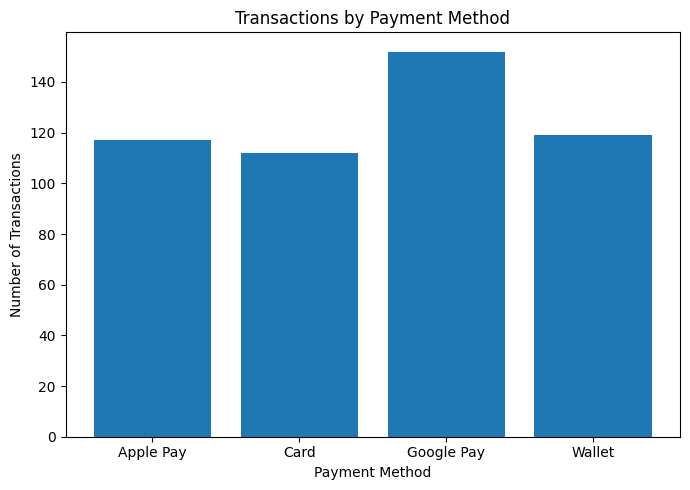

In [10]:
#Bar chart
plt.figure(figsize=(7,5))

plt.bar(transactions_payment.index,
transactions_payment["transaction_id"])

plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

Transactions Status Distribution

In [11]:
status = df["transaction_status"].value_counts()
status

transaction_status
Success    251
Failed     249
Name: count, dtype: int64

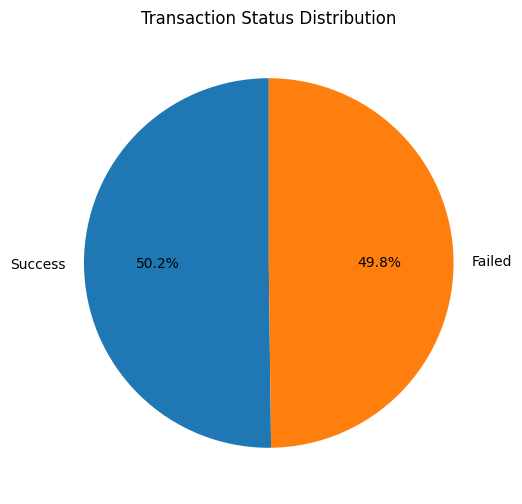

In [12]:
#Pie chart
plt.figure(figsize=(6,6)) #width = 6 and height = 6

plt.pie(status,      #this provides the sizes of the slice
labels=status.index, #this tells matplotlib what text to display on each slide  
autopct="%1.1f%%",   #this displays the percentage on each slide, % - start formatting, 1-minimum width, .1 - show one decimal place, f - display as a floating point number, %% - print % symbol
startangle=90)       #rotates the chart so it starts from the 12 o'clock position 

plt.title("Transaction Status Distribution")  

plt.show()

Transaction Amount Distribution

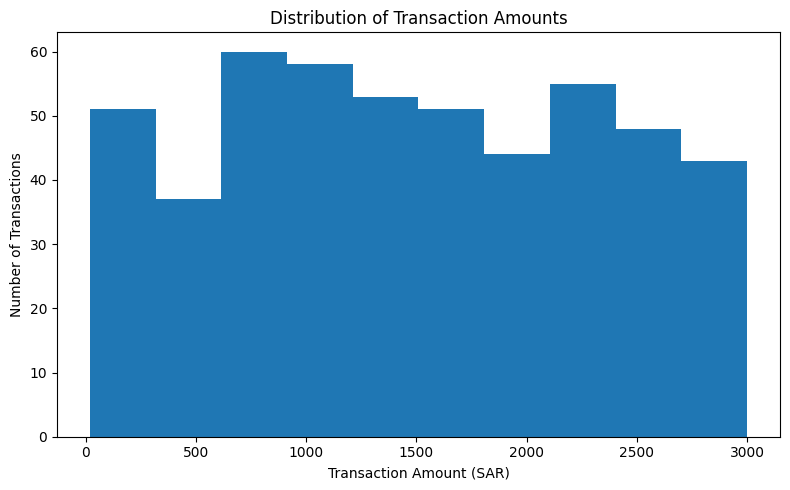

In [ ]:
#A histogram needs only one column
#A histogram shows us the frequency of each interval    
plt.figure(figsize=(8,5))

plt.hist(df["amount"],bins=10) #creates a histogram - groups continuous number into ranges

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount (SAR)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

Cashback Distribution

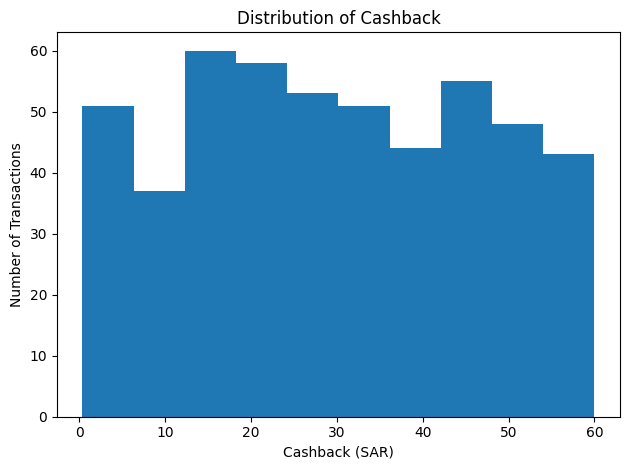

In [ ]:
#Histogram
plt.hist(df["cashback"],bins=10)

plt.title("Distribution of Cashback")
plt.xlabel("Cashback (SAR)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

Transaction Amount vs Cashback

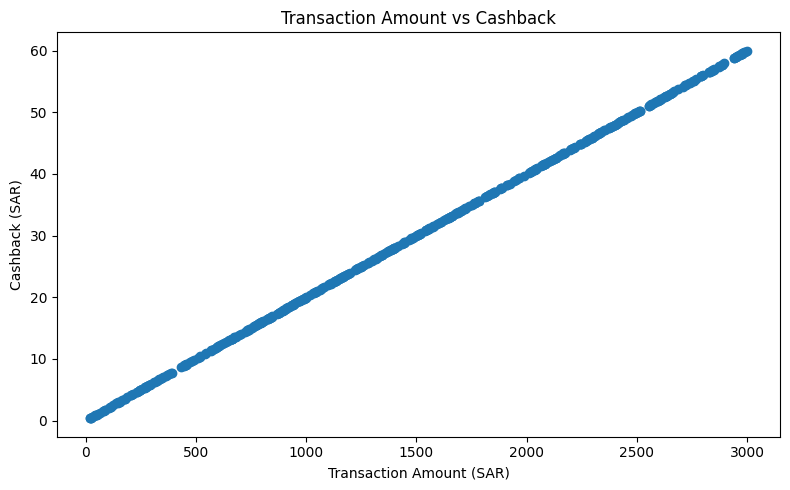

In [ ]:
#Scatter Plot
plt.figure(figsize=(8,5))

plt.scatter(df["amount"],df["cashback"])


plt.title("Transaction Amount vs Cashback")
plt.xlabel("Transaction Amount (SAR)")
plt.ylabel("Cashback (SAR)")

plt.tight_layout()
plt.show()